# Experiment 15: Handwritten digit using CNN

**Name:** Arshan Attar  
**Roll Number:** 231408  


In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

Imports TensorFlow and Keras libraries for building and training the Convolutional Neural Network (CNN). Also imports the MNIST handwritten digit dataset.

In [26]:
# 1. Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

Loads the MNIST dataset containing 60,000 training images and 10,000 testing images of handwritten digits from 0 to 9.

In [27]:
# 2. Preprocess the data
# Reshape to include the color channel and normalize pixels to 0-1
X_train = X_train.reshape((60000, 28, 28, 1)).astype('float32') / 255
X_test = X_test.reshape((10000, 28, 28, 1)).astype('float32') / 255

Reshapes the images into 28×28×1 format for the CNN. The pixel values are divided by 255 to normalize them from 0–255 to a range of 0–1.

In [28]:
# 3. Build the Convolutional Neural Network (CNN)
model = models.Sequential()

# First Convolutional Layer + Pooling
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))

# Second Convolutional Layer + Pooling
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Flattening layer
model.add(layers.Flatten())

# Dense (Fully Connected) layers
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Builds a Convolutional Neural Network (CNN) using different layers. The convolution and pooling layers extract important features from the handwritten images. The Flatten layer converts the features into a single array, and the Dense layers classify the image into one of the 10 digits (0–9).

In [29]:
# 4. Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Compiles the model using Adam optimizer, sparse categorical crossentropy as the loss function, and accuracy to measure the model's performance.

In [36]:
# 5. Train the model
print("Training the model...")
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Training the model...
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.9994 - loss: 0.0017 - val_accuracy: 0.9930 - val_loss: 0.0465
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.9985 - loss: 0.0049 - val_accuracy: 0.9913 - val_loss: 0.0567
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.9989 - loss: 0.0037 - val_accuracy: 0.9918 - val_loss: 0.0529
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.9992 - loss: 0.0022 - val_accuracy: 0.9913 - val_loss: 0.0476
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.9992 - loss: 0.0026 - val_accuracy: 0.9908 - val_loss: 0.0539
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.9991 - loss: 0.0030 - val_accuracy: 0.9908 - val_loss: 0.0581
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.9994 - loss: 0.0021 - val_accuracy: 0.9917 - val_loss: 0.0494
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 29ms/step - accuracy: 0.

Trains the CNN for 10 epochs using batches of 64 images. 10% of the training data is used for validation, and the training results are stored in the history variable.

In [38]:
# 6. Evaluate the model
print("Evaluating the model...")
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

Evaluating the model...
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9907 - loss: 0.0488
Test Accuracy: 0.9907


Evaluates the trained CNN using the test images and displays the final test accuracy of the model.

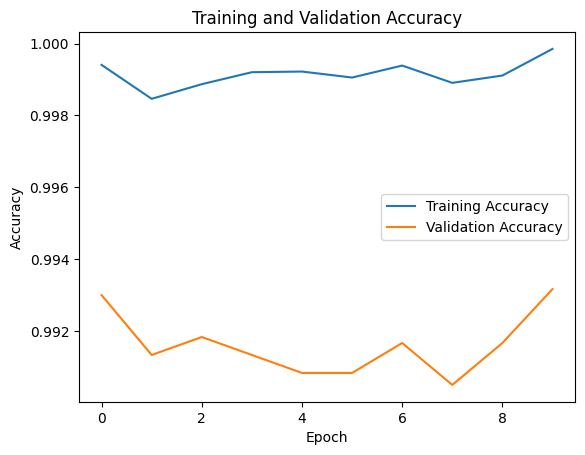

In [39]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

This graph shows the training and validation accuracy of the CNN over 10 epochs. The training accuracy remains very high, around 99.8% to 99.9%, while the validation accuracy stays around 98.8% to 99.2%. This shows that the CNN is learning the handwritten digit patterns very well and is also performing well on validation data.

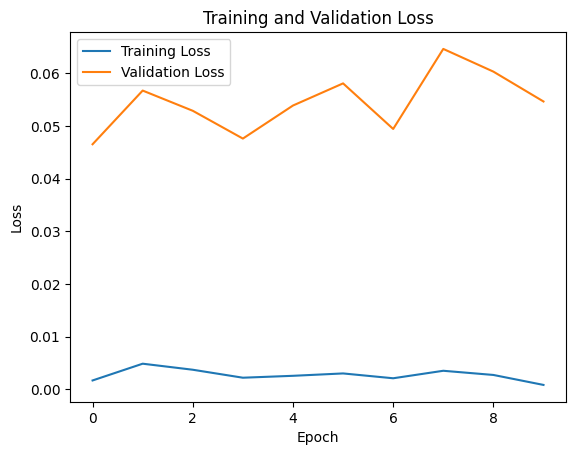

In [40]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

This graph shows the Training Loss and Validation Loss of the CNN over 10 epochs. Training loss shows the error on the training data, while validation loss shows the error on the validation data. The training loss remains very low and generally decreases, which means the model is learning well. The validation loss is higher and changes between epochs, showing how the model performs on unseen validation data.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


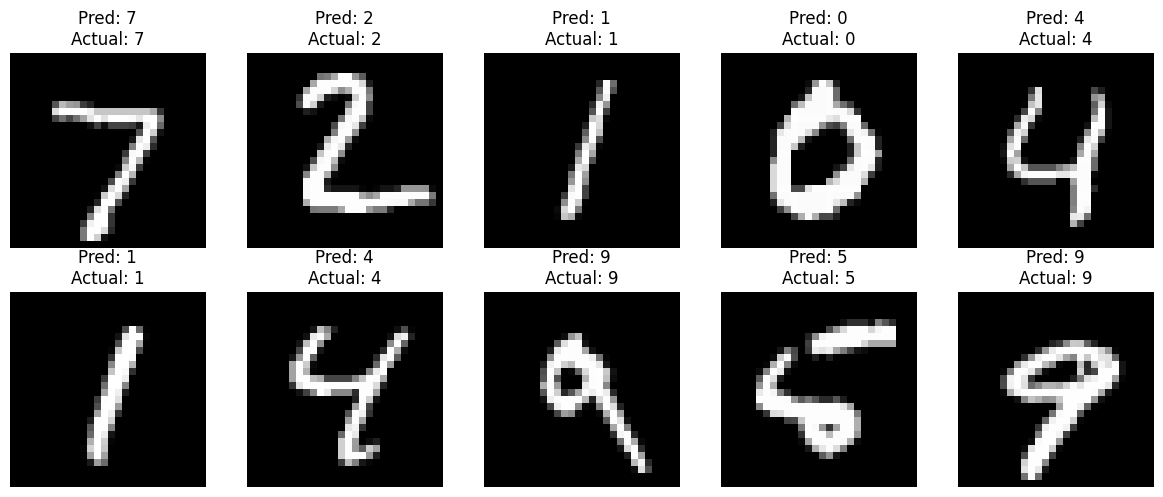

In [41]:
predictions = model.predict(X_test[:10])
predicted_labels = predictions.argmax(axis=1)

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {predicted_labels[i]}\nActual: {y_test[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

The trained CNN predicts the first 10 test images. Each image shows the predicted digit and the actual digit, allowing us to check whether the model recognized the handwritten digit correctly.

In [37]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,792 (1.40 MB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 243,862 (952.59 KB)

Displays the CNN architecture, output shape of each layer, and the number of parameters used by the model.